In [1]:
import math
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wandb
from wandb.apis.public.runs import Run

In [2]:
api = wandb.Api()

In [3]:
runs = api.runs(
    "graphcore/llama-mobile",
    filters={"config.name": "lr-sweep-17-03-26", "state": "finished"},
)

In [4]:
# Return (metric, relaxed_metric)
def get_metrics(task: str) -> tuple[str]:
    from eval.vqa import TASKS

    metrics, relaxed_metrics = TASKS[task].METRICS, TASKS[task].RELAXED_METRICS
    assert len(metrics) == 1 and len(relaxed_metrics) == 1
    return (metrics[0], relaxed_metrics[0])


def cleanup_run(run: Run) -> dict[str, Any] | None:
    d = {}
    d["name"] = run.name
    d["n_steps"] = run.config["training"]["n_steps"]
    d["lr_exponent"] = math.log2(run.config["training"]["optimiser"]["lr"])

    for task in ["vqa", "ai2d", "chartqa", "docvqa"]:
        m, relaxed_m = get_metrics(task)
        d[task] = run.summary[f"downstream.{task}.{m}"]
        d[f"{task}_relaxed"] = run.summary[f"downstream.{task}.{relaxed_m}"]

    history = run.history()
    d["train_loss"] = (
        np.mean(history["train/loss"].tail(10).values)
        if "train/loss" in history
        else None
    )
    d["val_loss"] = run.summary["val/loss"] if "val/loss" in run.summary else None

    return d

In [8]:
df = pd.DataFrame([cleanup_run(run) for run in runs])

In [9]:
df.sort_values(by=["n_steps", "lr_exponent"], ascending=True, inplace=True)

In [10]:
df

,name,n_steps,lr_exponent,vqa,vqa_relaxed,ai2d,ai2d_relaxed,chartqa,chartqa_relaxed,docvqa,docvqa_relaxed,train_loss,val_loss
1,lyric-meadow-1726,1024,-18.0,0.677409,0.754557,0.515625,0.541016,0.659180,0.846680,0.567849,0.825195,0.052970,0.065456
5,silvery-bird-1730,1024,-17.0,0.706706,0.754557,0.303711,0.336914,0.617188,0.833984,0.748086,0.826172,0.048926,0.062889
3,sweet-vortex-1728,1024,-16.0,0.718750,0.759766,0.424805,0.459961,0.559570,0.830078,0.773522,0.828125,0.048419,0.065832
2,vibrant-star-1727,2048,-18.0,0.705078,0.759440,0.482422,0.539062,0.658203,0.836914,0.728021,0.837891,0.043338,0.055303
0,sleek-pyramid-1725,2048,-17.0,0.716471,0.761719,0.492188,0.545898,0.640625,0.841797,0.763556,0.831055,0.039730,0.053646
4,sunny-music-1729,2048,-16.0,0.704753,0.769531,0.244141,0.283203,0.584961,0.815430,0.740604,0.829102,0.040569,0.057950


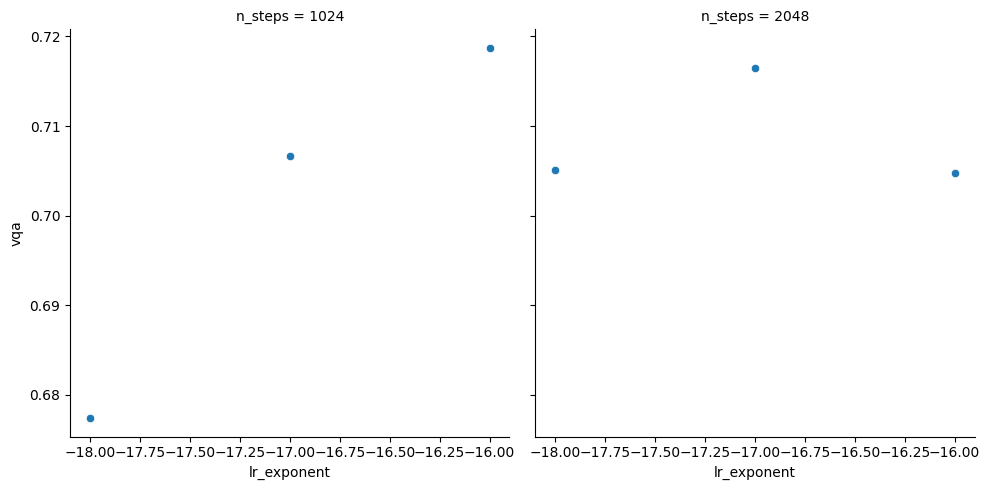

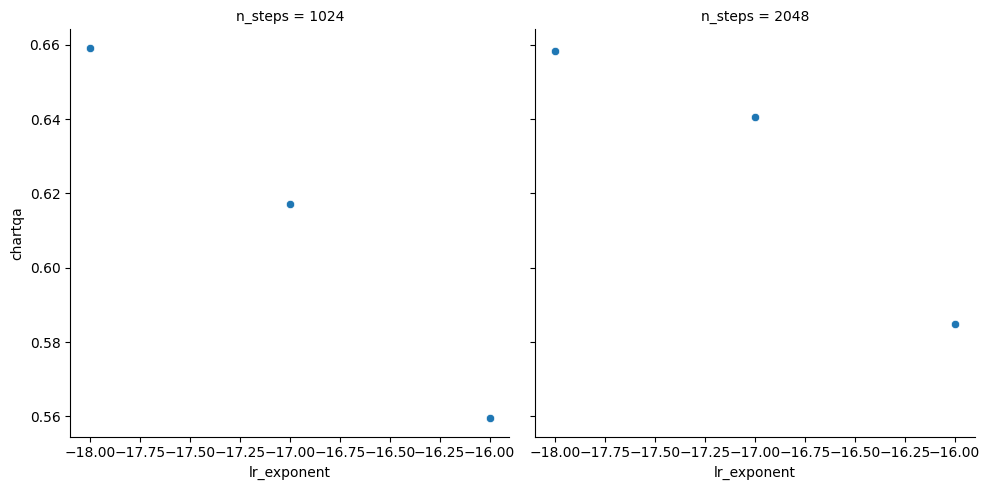

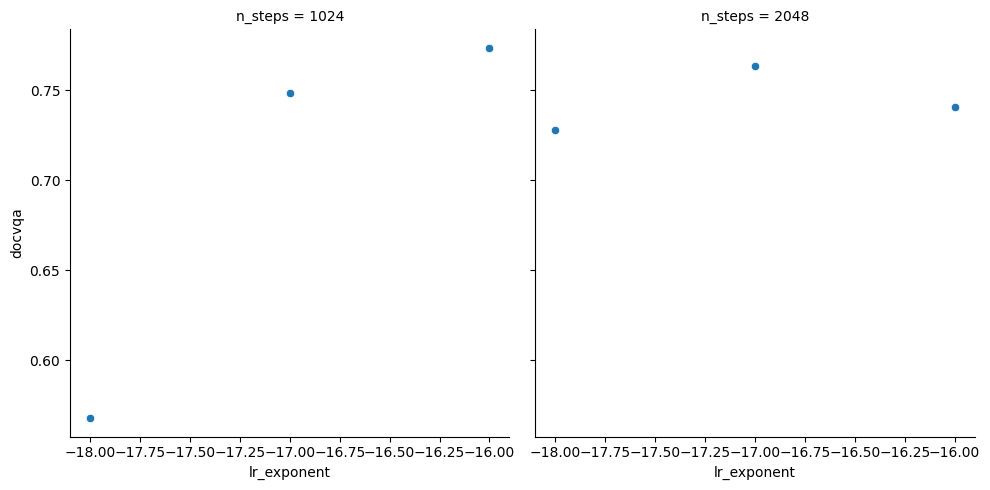

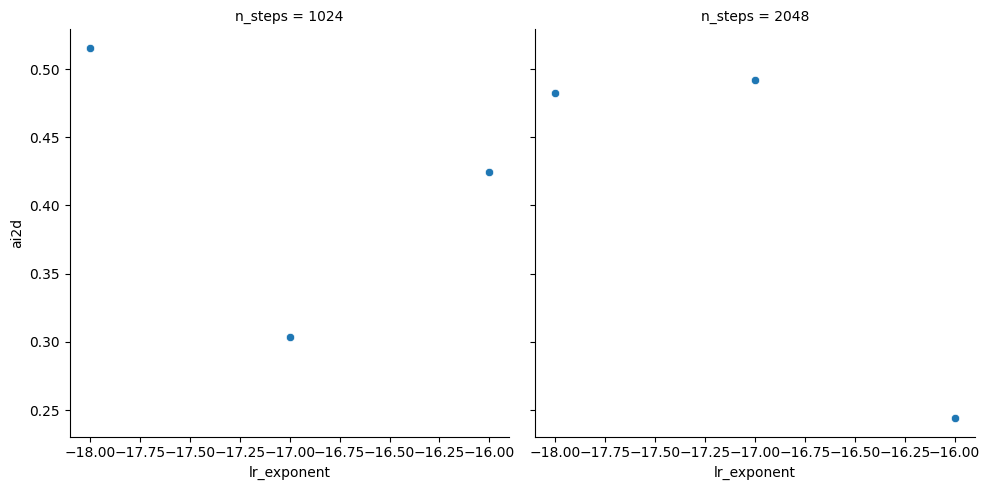

In [12]:
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for task in tasks:
    g = sns.relplot(data=df, x="lr_exponent", y=task, col="n_steps")

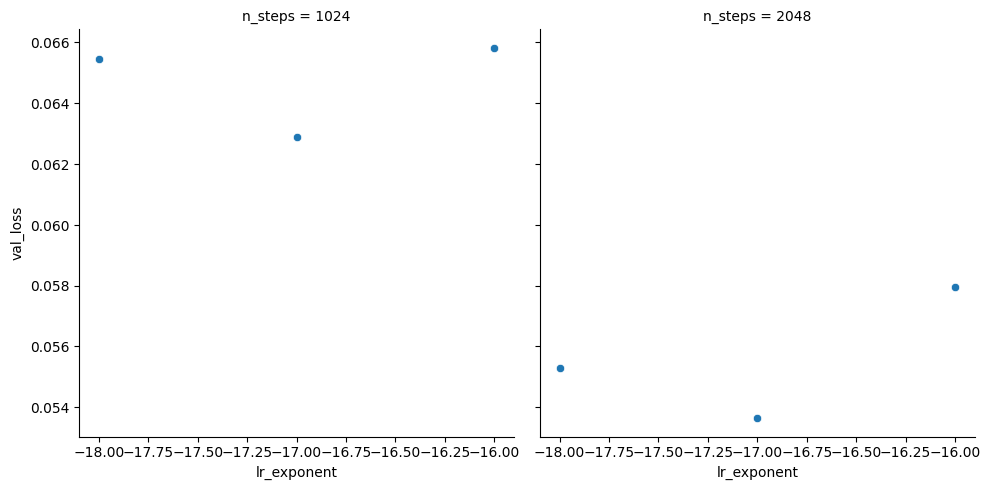

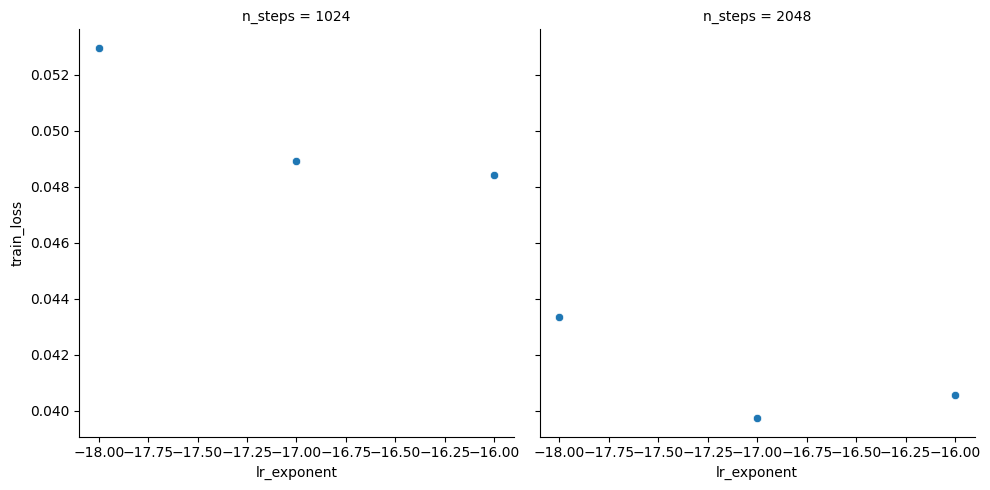

In [14]:
g = sns.relplot(data=df, x="lr_exponent", y="val_loss", col="n_steps")
g = sns.relplot(data=df, x="lr_exponent", y="train_loss", col="n_steps")

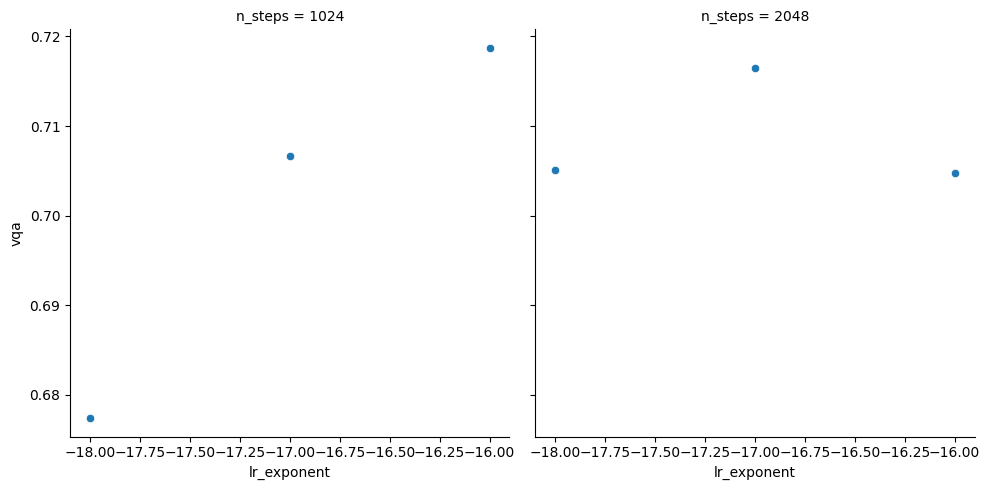

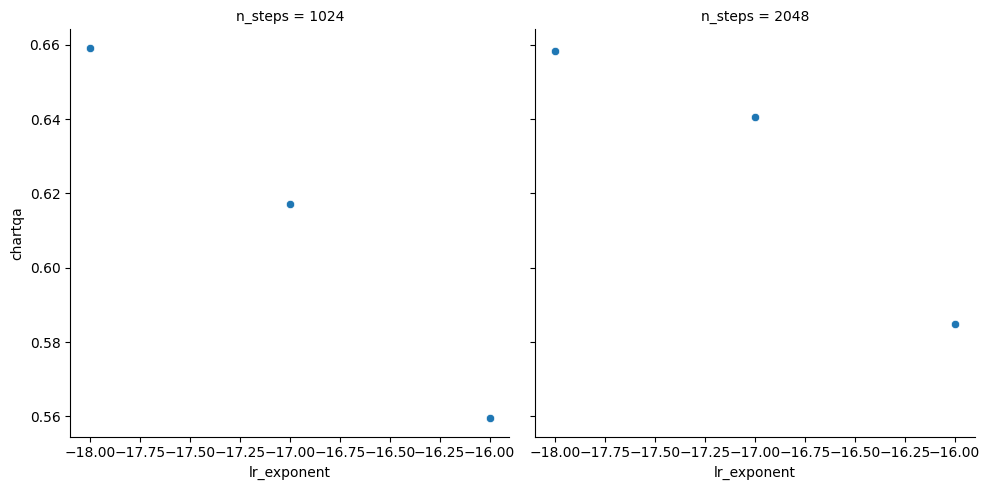

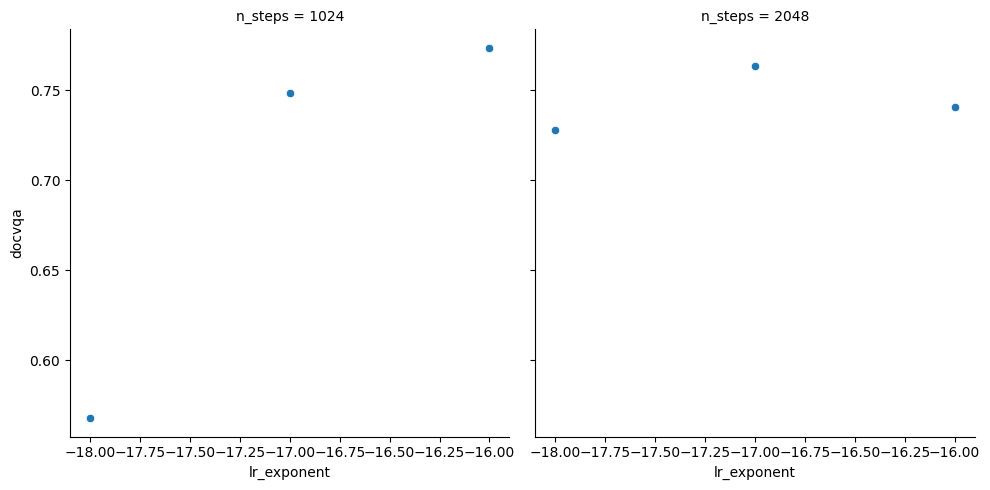

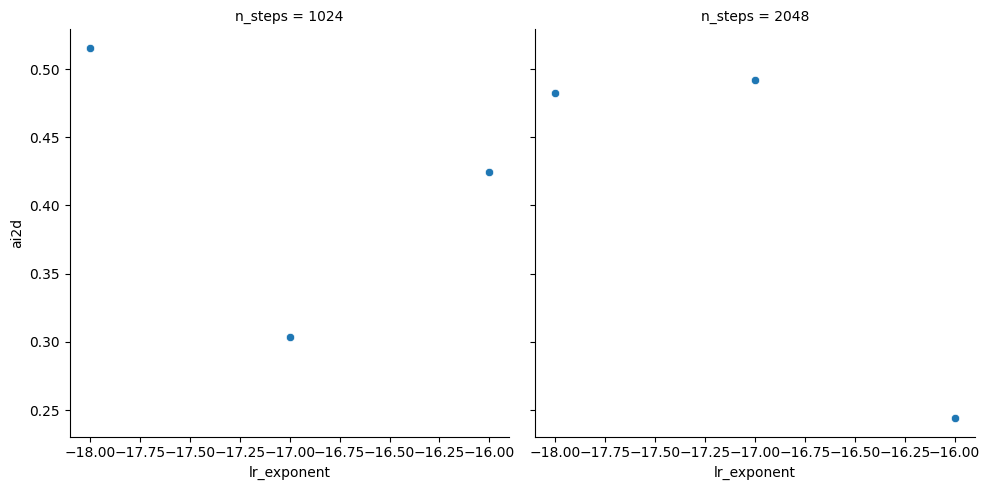

In [15]:
tasks = ["vqa", "chartqa", "docvqa", "ai2d"]
for task in tasks:
    g = sns.relplot(data=df, x="lr_exponent", y=task, col="n_steps")